In [1]:
# Install packages
import sys
!{sys.executable} -m pip install torch torchvision scikit-learn matplotlib seaborn pillow tqdm pandas numpy --quiet  # noqa: E501


In [4]:
# Imports
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from pathlib import Path

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

# Sklearn Metrics 
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)
# Reproducibility 
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

#  Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cpu


In [6]:
 # Manual download from:
# https://www.kaggle.com/datasets/imrandude/nct-crc-he-100k


from pathlib import Path

# Dataset path
DATA_ROOT = Path(r"/Users/Documents/komal/NCT-CRC-HE-100K")

# ─── Class mapping ─────────────────────────────────────────────
CLASS_MAP = {
    'TUM':  {'cancer': 1, 'risk': 1},
    'STR':  {'cancer': 0, 'risk': 1},
    'MUC':  {'cancer': 0, 'risk': 1},
    'NORM': {'cancer': 0, 'risk': 0},
    'LYM':  {'cancer': 0, 'risk': 0},
    'MUS':  {'cancer': 0, 'risk': 0},
    'ADI':  {'cancer': 0, 'risk': 0},
    'DEB':  {'cancer': 0, 'risk': 0},
    'BACK': {'cancer': 0, 'risk': 0},
}
print('Class mapping defined:')
for cls, labels in CLASS_MAP.items():
    print(f'  {cls:4s} → cancer={labels["cancer"]}, risk={labels["risk"]}')

Class mapping defined:
  TUM  → cancer=1, risk=1
  STR  → cancer=0, risk=1
  MUC  → cancer=0, risk=1
  NORM → cancer=0, risk=0
  LYM  → cancer=0, risk=0
  MUS  → cancer=0, risk=0
  ADI  → cancer=0, risk=0
  DEB  → cancer=0, risk=0
  BACK → cancer=0, risk=0


In [7]:
#Imagecheck

from PIL import Image
import random

tum_path = DATA_ROOT / "TUM"

img_files = list(tum_path.glob("*"))

if len(img_files) > 0:
    img = Image.open(random.choice(img_files))
    print("Sample image loaded successfully:", img.size)
else:
    print("No images found in TUM folder")

Sample image loaded successfully: (224, 224)


In [13]:
# Multiple Instance learning (MIL) 


class MILDataset(Dataset):


    def __init__(self, data_root, num_bags=1200, bag_size=32,
                 split='train', split_ratio=(0.67, 0.17, 0.16),
                 transform=None, seed=42):
       
        set_seed(seed)
        self.bag_size  = bag_size
        self.transform = transform

        # Collect all patch paths per class
        self.class_paths = {}
        for cls in CLASS_MAP:
            folder = Path(data_root) / cls
            if folder.exists():
                self.class_paths[cls] = sorted(folder.glob('*.tif'))
                # Also accept .png, .jpg
                if not self.class_paths[cls]:
                    self.class_paths[cls] = (
                        sorted(folder.glob('*.png')) +
                        sorted(folder.glob('*.jpg'))
                    )
            else:
                print(f'Warning: folder not found: {folder}')
                self.class_paths[cls] = []

        # Bags creation
        self.bags = self._create_bags(num_bags)

        # ── Train / val / test split
        n_train = int(num_bags * split_ratio[0])   
        n_val   = int(num_bags * split_ratio[1])  
        if split == 'train':
            self.bags = self.bags[:n_train]
        elif split == 'val':
            self.bags = self.bags[n_train:n_train + n_val]
        else:  # test
            self.bags = self.bags[n_train + n_val:]

        print(f'[{split.upper()}] {len(self.bags)} bags | bag_size={bag_size}')

    def _create_bags(self, num_bags):
        
        bags = []
        all_classes = list(CLASS_MAP.keys())

        for _ in range(num_bags):
            # Randomly choose bag_size patches from random classes
            patch_paths, patch_labels = [], []
            for _ in range(self.bag_size):
                cls = random.choice(all_classes)
                if self.class_paths[cls]:
                    p = random.choice(self.class_paths[cls])
                    patch_paths.append(p)
                    patch_labels.append(CLASS_MAP[cls])

            # Bag is cancer if ANY patch is TUM
            bag_cancer = int(any(l['cancer'] == 1 for l in patch_labels))
            bag_risk   = int(any(l['risk']   == 1 for l in patch_labels))
            bags.append((patch_paths, bag_cancer, bag_risk))

        return bags

    def __len__(self):
        return len(self.bags)

    def __getitem__(self, idx):
        patch_paths, cancer_label, risk_label = self.bags[idx]
        patches = []
        for p in patch_paths:
            img = Image.open(p).convert('RGB')
            if self.transform:
                img = self.transform(img)
            patches.append(img)

        
        patches = torch.stack(patches)
        return patches, torch.tensor(cancer_label), torch.tensor(risk_label)


# ImageNet normalisation for pretrained ResNet
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

# Datasets & loaders
train_dataset = MILDataset(DATA_ROOT, num_bags=1200, bag_size=32,
                           split='train', transform=train_transform)
val_dataset   = MILDataset(DATA_ROOT, num_bags=1200, bag_size=32,
                           split='val',   transform=val_transform)
test_dataset  = MILDataset(DATA_ROOT, num_bags=1200, bag_size=32,
                           split='test',  transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False, num_workers=0)


[TRAIN] 804 bags | bag_size=32
[VAL] 204 bags | bag_size=32
[TEST] 192 bags | bag_size=32


In [14]:
# Feature Extractor: ResNet-50 and MLP

class FeatureExtractor(nn.Module):
   

    def __init__(self, out_dim=512, dropout=0.25, freeze_backbone=True):
        super().__init__()

        #  Load  ResNet-50 
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

        
        self.backbone = nn.Sequential(*list(backbone.children())[:-1])

        
        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

        #  MLP: 
       
        self.projector = nn.Sequential(
            nn.Linear(2048, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        # x: (batch, 3, 224, 224)
        feats = self.backbone(x)          
        feats = feats.flatten(1)          
        feats = self.projector(feats)    
        return feats


# check
extractor = FeatureExtractor(out_dim=512).to(DEVICE)
dummy = torch.randn(4, 3, 224, 224).to(DEVICE)
out   = extractor(dummy)
print(f'FeatureExtractor output shape: {out.shape}') 

FeatureExtractor output shape: torch.Size([4, 512])


In [15]:
# Gated Attention MIL

class GatedAttentionMIL(nn.Module):
    

    def __init__(self, L=512, D=256, dropout=0.25):
        
        super().__init__()

        #  V branch: Relevance (Tanh)
       
        self.attention_V = nn.Sequential(
            nn.Linear(L, D),
            nn.Tanh()
        )

        # ── U branch: Gate (Sigmoid)
    
        self.attention_U = nn.Sequential(
            nn.Linear(L, D),
            nn.Sigmoid()
        )

        # Scoring vector
        
        self.attention_w = nn.Linear(D, 1)

        self.dropout = nn.Dropout(dropout)

    def forward(self, h):
       
        h = self.dropout(h)

        #  Gated attention computation
        # 1: V-branch (relevance)
        A_V = self.attention_V(h)           

        #  2: U-branch (gate)
        A_U = self.attention_U(h)          

        #  3: Element-wise multiplication (Relevance × Gate)
        A   = A_V * A_U            
        
        #  4: Score each patch with learnable vector w
        A   = self.attention_w(A)           

        #  5: Softmax → attention weights sum to 1
        A   = F.softmax(A, dim=0)          
        
        #  6: Weighted sum → bag representation
        z   = (A * h).sum(dim=0)            

        return z, A.squeeze(1)              

# check
attn_mil = GatedAttentionMIL(L=512, D=256).to(DEVICE)
fake_bag  = torch.randn(32, 512).to(DEVICE)  
z, weights = attn_mil(fake_bag)
print(f'Bag representation shape : {z.shape}')       
print(f'Attention weights shape  : {weights.shape}') 
print(f'Attention weights sum    : {weights.sum():.4f}')  

Bag representation shape : torch.Size([512])
Attention weights shape  : torch.Size([32])
Attention weights sum    : 1.0000


In [16]:
#  MIL Model, Feature Extractor + Gated Attention + Dual Heads

class MILCancerModel(nn.Module):
    

    def __init__(self, feat_dim=512, attn_dim=256, dropout=0.25):
        super().__init__()

        #  Components
        self.feature_extractor = FeatureExtractor(out_dim=feat_dim,
                                                  dropout=dropout,
                                                  freeze_backbone=True)
        self.mil_attention = GatedAttentionMIL(L=feat_dim, D=attn_dim,
                                               dropout=dropout)

        #  Cancer: Tumour vs Normal
        self.cancer_head = nn.Sequential(
            nn.Linear(feat_dim, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(64, 2)      
        )

        # Risk: High Risk vs Low Risk 
        self.risk_head = nn.Sequential(
            nn.Linear(feat_dim, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(64, 2)      
        )

    def forward(self, bags):
        
        batch_size = bags.shape[0]
        cancer_logits_list = []
        risk_logits_list   = []
        attention_all      = []

        for i in range(batch_size):
            # Single bag: (bag_size, 3, 224, 224)
            patches = bags[i]

            #  1: Extract features for each patch
            
            patch_feats = self.feature_extractor(patches)

            #  2: Gated attention pooling
           
            bag_repr, attn_weights = self.mil_attention(patch_feats)

            # Step 3: Classify
            
            cancer_logits_list.append(self.cancer_head(bag_repr))
            risk_logits_list.append(self.risk_head(bag_repr))
            attention_all.append(attn_weights)

        cancer_logits = torch.stack(cancer_logits_list)   
        risk_logits   = torch.stack(risk_logits_list)    

        return cancer_logits, risk_logits, attention_all


# Model
model = MILCancerModel(feat_dim=512, attn_dim=256, dropout=0.25).to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable:,}')

Total parameters    : 24,885,957
Trainable parameters: 1,377,925


In [17]:
#  Training

# Loss function 
criterion = nn.CrossEntropyLoss()

# Combined loss
CANCER_WEIGHT = 0.7
RISK_WEIGHT   = 0.3

# AdamW Optimiser
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-5
)

# Cosine Annealing
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=30, eta_min=1e-6
)

#Training Loop

def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss, cancer_correct, risk_correct, n = 0., 0, 0, 0

    for bags, cancer_labels, risk_labels in tqdm(loader, desc='Train', leave=False):
        bags          = bags.to(DEVICE)
        cancer_labels = cancer_labels.to(DEVICE)
        risk_labels   = risk_labels.to(DEVICE)

        optimizer.zero_grad()

        # Forward pass
        cancer_logits, risk_logits, _ = model(bags)

        # Compute weighted loss
        loss = (CANCER_WEIGHT * criterion(cancer_logits, cancer_labels) +
                RISK_WEIGHT   * criterion(risk_logits,   risk_labels))

        # Backward pass
        loss.backward()

        # Gradient clipping 
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        # Accumulate stats
        total_loss     += loss.item() * bags.size(0)
        cancer_correct += (cancer_logits.argmax(1) == cancer_labels).sum().item()
        risk_correct   += (risk_logits.argmax(1)   == risk_labels  ).sum().item()
        n              += bags.size(0)

    return total_loss / n, cancer_correct / n, risk_correct / n


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss, cancer_correct, risk_correct, n = 0., 0, 0, 0

    for bags, cancer_labels, risk_labels in tqdm(loader, desc='Eval', leave=False):
        bags          = bags.to(DEVICE)
        cancer_labels = cancer_labels.to(DEVICE)
        risk_labels   = risk_labels.to(DEVICE)

        cancer_logits, risk_logits, _ = model(bags)

        loss = (CANCER_WEIGHT * criterion(cancer_logits, cancer_labels) +
                RISK_WEIGHT   * criterion(risk_logits,   risk_labels))

        total_loss     += loss.item() * bags.size(0)
        cancer_correct += (cancer_logits.argmax(1) == cancer_labels).sum().item()
        risk_correct   += (risk_logits.argmax(1)   == risk_labels  ).sum().item()
        n              += bags.size(0)

    return total_loss / n, cancer_correct / n, risk_correct / n


# Run Training 
EPOCHS      = 30
best_val_loss = float('inf')
CHECKPOINT  = './best_model.pth'

history = {'train_loss': [], 'val_loss': [],
           'train_cancer_acc': [], 'val_cancer_acc': []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_c_acc, tr_r_acc = train_one_epoch(model, train_loader, optimizer)
    vl_loss, vl_c_acc, vl_r_acc = evaluate(model, val_loader)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_cancer_acc'].append(tr_c_acc)
    history['val_cancer_acc'].append(vl_c_acc)

    #  Model
    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        torch.save(model.state_dict(), CHECKPOINT)
        flag = '  ← best'
    else:
        flag = ''

    print(f'Epoch {epoch:02d}/{EPOCHS} | '
          f'Train Loss: {tr_loss:.4f} | Cancer Acc: {tr_c_acc:.3f} | '
          f'Val Loss: {vl_loss:.4f} | Cancer Acc: {vl_c_acc:.3f}{flag}')

print(f'\nBest validation loss: {best_val_loss:.4f}')

Epoch 01/30 | Train Loss: 0.1311 | Cancer Acc: 0.970 | Val Loss: 0.0650 | Cancer Acc: 0.985  ← best


Epoch 02/30 | Train Loss: 0.0494 | Cancer Acc: 0.989 | Val Loss: 0.0543 | Cancer Acc: 0.985  ← best


Epoch 03/30 | Train Loss: 0.0519 | Cancer Acc: 0.989 | Val Loss: 0.0532 | Cancer Acc: 0.985  ← best


Epoch 04/30 | Train Loss: 0.0466 | Cancer Acc: 0.989 | Val Loss: 0.0578 | Cancer Acc: 0.985


Epoch 05/30 | Train Loss: 0.0481 | Cancer Acc: 0.989 | Val Loss: 0.0586 | Cancer Acc: 0.985


...

Epoch 26/30 | Train Loss: 0.0426 | Cancer Acc: 0.989 | Val Loss: 0.0546 | Cancer Acc: 0.985


Epoch 27/30 | Train Loss: 0.0484 | Cancer Acc: 0.989 | Val Loss: 0.0546 | Cancer Acc: 0.985


Epoch 28/30 | Train Loss: 0.0463 | Cancer Acc: 0.989 | Val Loss: 0.0544 | Cancer Acc: 0.985


Epoch 29/30 | Train Loss: 0.0423 | Cancer Acc: 0.989 | Val Loss: 0.0546 | Cancer Acc: 0.985


Epoch 30/30 | Train Loss: 0.0472 | Cancer Acc: 0.989 | Val Loss: 0.0547 | Cancer Acc: 0.985

Best validation loss: 0.0532


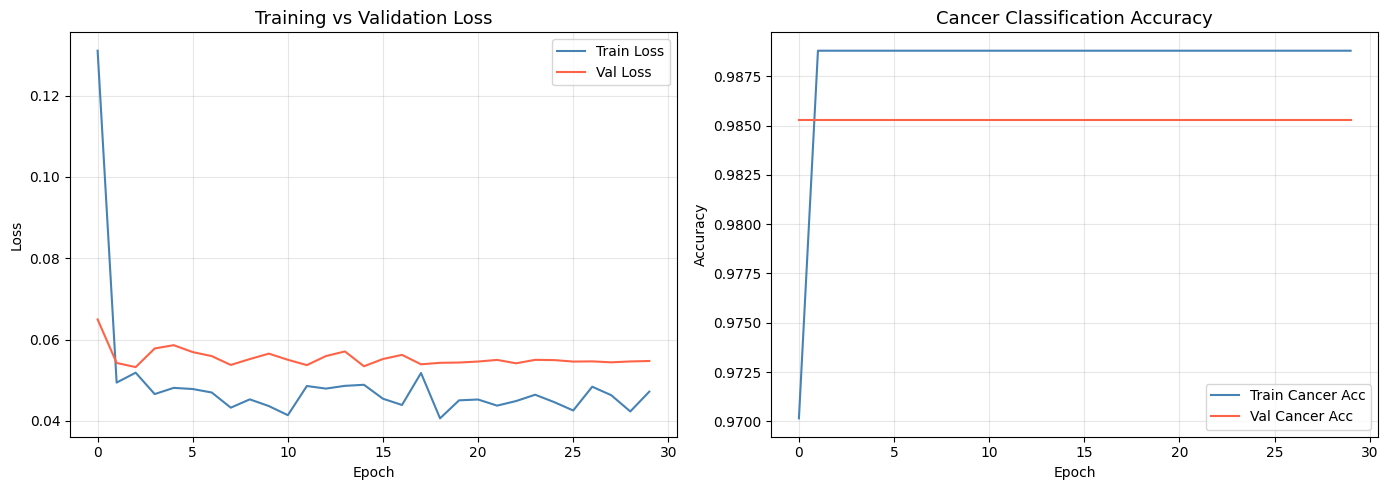

Saved training_curves.png


In [18]:


# Plot Training Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history['train_loss'], label='Train Loss', color='steelblue')
axes[0].plot(history['val_loss'],   label='Val Loss',   color='tomato')
axes[0].set_title('Training vs Validation Loss', fontsize=13)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(history['train_cancer_acc'], label='Train Cancer Acc', color='steelblue')
axes[1].plot(history['val_cancer_acc'],   label='Val Cancer Acc',   color='tomato')
axes[1].set_title('Cancer Classification Accuracy', fontsize=13)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved training_curves.png')

Predicted cancer: Tumour | True: Tumour
Predicted risk  : High | True: High


/var/folders/fz/9y8hs0316c171p26yry1sbn40000gn/T/ipykernel_7931/3496157109.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet     = cm.get_cmap('jet')


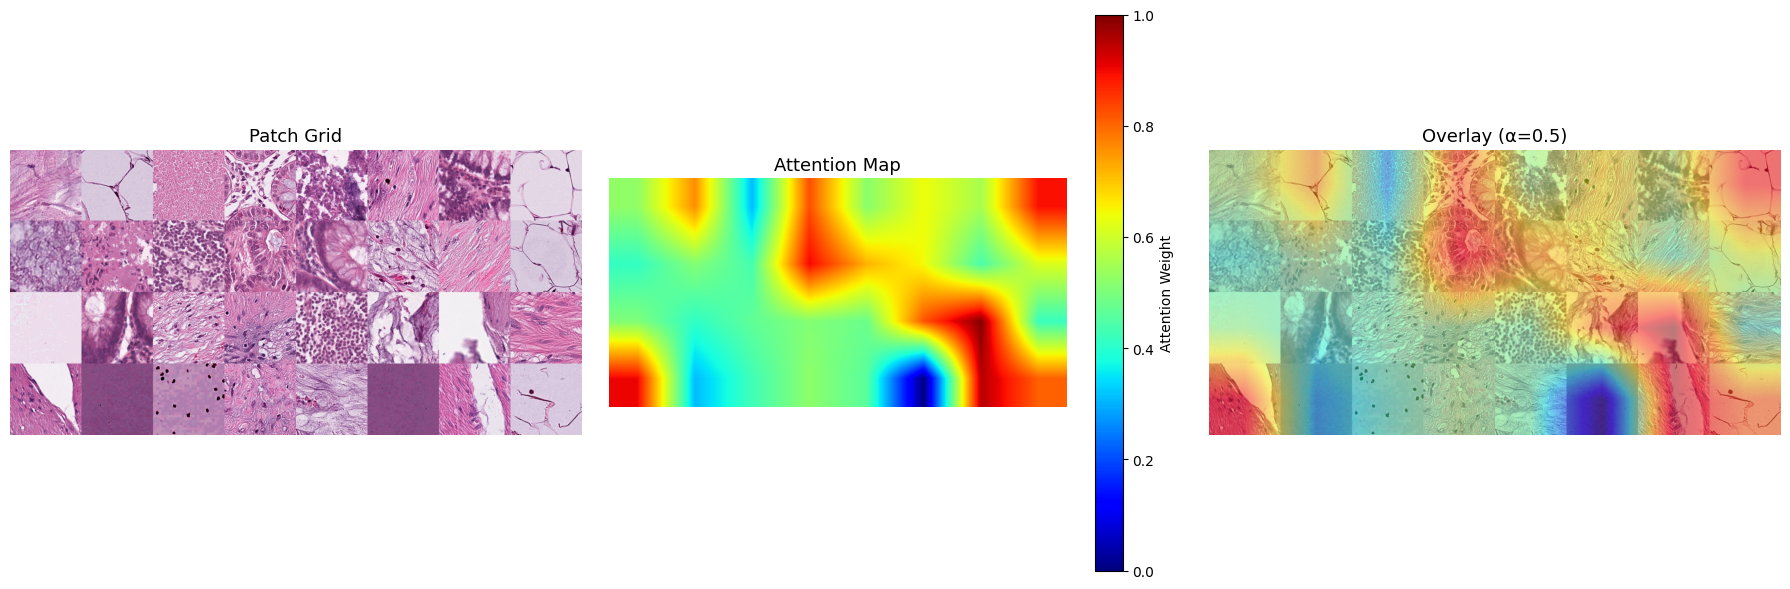

Saved attention_heatmap.png


In [19]:
# Attention Heatmap Generation

def generate_attention_heatmap(patch_images, attention_weights,
                                n_cols=8, patch_size=224, alpha=0.5):
    
    n_patches = len(patch_images)
    n_rows    = (n_patches + n_cols - 1) // n_cols 
    canvas_w  = n_cols * patch_size
    canvas_h  = n_rows * patch_size

    #  Build patch grid canvas
    canvas = Image.new('RGB', (canvas_w, canvas_h), color=(220, 220, 220))
    for i, img in enumerate(patch_images):
        row, col = divmod(i, n_cols)
        canvas.paste(img.resize((patch_size, patch_size)),
                     (col * patch_size, row * patch_size))

    # Build low-res attention map 
    attn = np.zeros(n_rows * n_cols)
    attn[:n_patches] = attention_weights
    attn = attn.reshape(n_rows, n_cols)

    # Normalise to [0, 1]
    attn = (attn - attn.min()) / (attn.max() - attn.min() + 1e-8)

    # Upsample to canvas resolution using bilinear interpolation
    from PIL import Image as PILImage
    attn_img = PILImage.fromarray((attn * 255).astype(np.uint8))
    attn_img = attn_img.resize((canvas_w, canvas_h), PILImage.BILINEAR)
    attn_arr = np.array(attn_img) / 255.0 

    
    jet     = cm.get_cmap('jet')
    heatmap = jet(attn_arr)[:, :, :3]      
    heatmap = (heatmap * 255).astype(np.uint8)
    heatmap_img = PILImage.fromarray(heatmap)

    #  heatmap 
    overlay = PILImage.blend(canvas, heatmap_img, alpha=alpha)

    # Plot 
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(canvas);      axes[0].set_title('Patch Grid',        fontsize=13)
    axes[1].imshow(attn_arr, cmap='jet', vmin=0, vmax=1)
    axes[1].set_title('Attention Map', fontsize=13)
    plt.colorbar(axes[1].images[0], ax=axes[1], label='Attention Weight')
    axes[2].imshow(overlay);     axes[2].set_title('Overlay (α=0.5)',   fontsize=13)

    for ax in axes:
        ax.axis('off')

    plt.tight_layout()
    return fig


# Load best checkpoint
model.load_state_dict(torch.load(CHECKPOINT, map_location=DEVICE))
model.eval()

# Get one test bag (raw patches before transform)
sample_bag_paths, cancer_lbl, risk_lbl = test_dataset.bags[0]

# Load PIL images (for visualisation)
pil_patches = [Image.open(p).convert('RGB') for p in sample_bag_paths]

# Get transformed tensor for the model
bag_tensor  = torch.stack([val_transform(img) for img in pil_patches])
bag_tensor  = bag_tensor.unsqueeze(0).to(DEVICE)  

with torch.no_grad():
    c_logits, r_logits, attn_list = model(bag_tensor)

attn_weights = attn_list[0].cpu().numpy()   # (32,)

pred_cancer = c_logits.argmax(1).item()     # 0=Normal, 1=Tumour
pred_risk   = r_logits.argmax(1).item()     # 0=Low, 1=High
print(f'Predicted cancer: {"Tumour" if pred_cancer else "Normal"} | '
      f'True: {"Tumour" if cancer_lbl else "Normal"}')
print(f'Predicted risk  : {"High" if pred_risk else "Low"} | '
      f'True: {"High" if risk_lbl else "Low"}')

# Generate heatmap
fig = generate_attention_heatmap(pil_patches, attn_weights)
fig.savefig('attention_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved attention_heatmap.png')

In [20]:
#  Test Set Evaluation 
model.load_state_dict(torch.load(CHECKPOINT, map_location=DEVICE))
model.eval()

all_cancer_true, all_cancer_pred, all_cancer_prob = [], [], []
all_risk_true,   all_risk_pred,   all_risk_prob   = [], [], []

with torch.no_grad():
    for bags, cancer_labels, risk_labels in tqdm(test_loader, desc='Testing'):
        bags = bags.to(DEVICE)
        c_logits, r_logits, _ = model(bags)

        c_probs = F.softmax(c_logits, dim=1)[:, 1].cpu().numpy()  
        r_probs = F.softmax(r_logits, dim=1)[:, 1].cpu().numpy()  
        
        all_cancer_true.extend(cancer_labels.numpy())
        all_cancer_pred.extend(c_logits.argmax(1).cpu().numpy())
        all_cancer_prob.extend(c_probs)

        all_risk_true.extend(risk_labels.numpy())
        all_risk_pred.extend(r_logits.argmax(1).cpu().numpy())
        all_risk_prob.extend(r_probs)

#  Metrics 
print('='*55)
print('        CANCER CLASSIFICATION RESULTS')
print('='*55)
print(classification_report(all_cancer_true, all_cancer_pred,
                             target_names=['Normal', 'Tumour']))
c_auc = roc_auc_score(all_cancer_true, all_cancer_prob)
print(f'AUC-ROC: {c_auc:.4f}')

print('\n' + '='*55)
print('           RISK PREDICTION RESULTS')
print('='*55)
print(classification_report(all_risk_true, all_risk_pred,
                             target_names=['Low Risk', 'High Risk']))
r_auc = roc_auc_score(all_risk_true, all_risk_prob)
print(f'AUC-ROC: {r_auc:.4f}')


Testing: 100%|██████████| 12/12 [09:22<00:00, 46.89s/it]

        CANCER CLASSIFICATION RESULTS
              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00         3
      Tumour       0.98      1.00      0.99       189

    accuracy                           0.98       192
   macro avg       0.49      0.50      0.50       192
weighted avg       0.97      0.98      0.98       192

AUC-ROC: 0.8801

           RISK PREDICTION RESULTS



/opt/homebrew/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


ValueError: Number of classes, 1, does not match size of target_names, 2. Try specifying the labels parameter

In [23]:
print("Unique true values:", set(all_risk_true))
print("Unique predicted values:", set(all_risk_pred))

print(classification_report(all_risk_true, all_risk_pred,
                             target_names=[ 'High Risk']))
r_auc = roc_auc_score(all_risk_true, all_risk_prob)
print(f'AUC-ROC: {r_auc:.4f}')

Unique true values: {np.int64(1)}
Unique predicted values: {np.int64(1)}
              precision    recall  f1-score   support

   High Risk       1.00      1.00      1.00       192

    accuracy                           1.00       192
   macro avg       1.00      1.00      1.00       192
weighted avg       1.00      1.00      1.00       192

AUC-ROC: nan


/opt/homebrew/lib/python3.14/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


/opt/homebrew/lib/python3.14/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


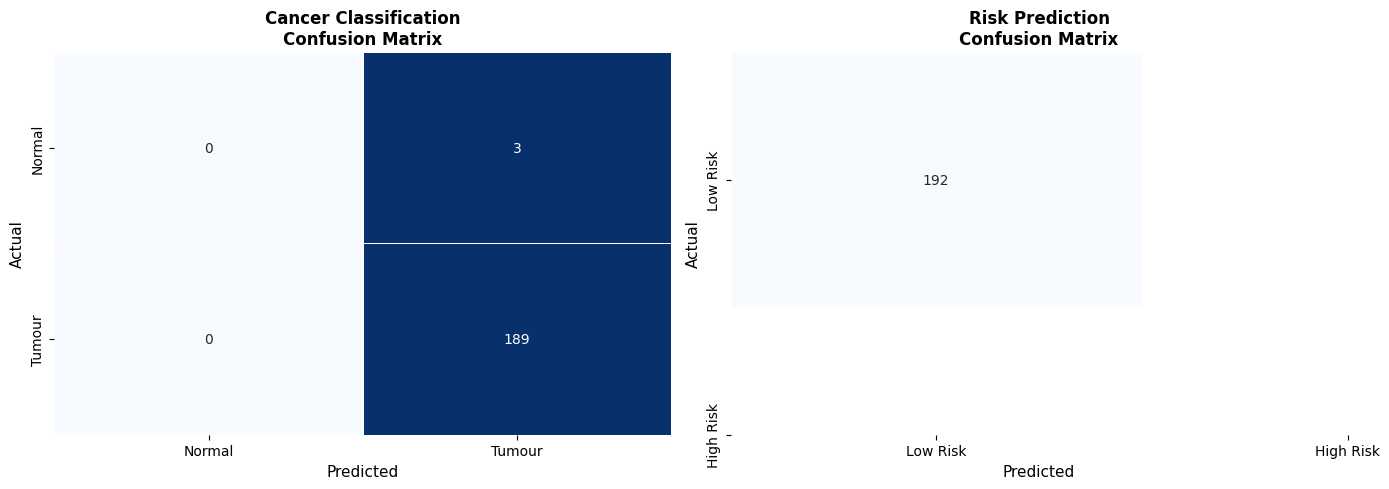

Saved confusion_matrices.png


In [24]:
# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_true, y_pred, labels, title in [
    (axes[0], all_cancer_true, all_cancer_pred,
     ['Normal', 'Tumour'],     'Cancer Classification'),
    (axes[1], all_risk_true,   all_risk_pred,
     ['Low Risk', 'High Risk'], 'Risk Prediction'),
]:
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=cm, fmt='d', ax=ax,
                cmap='Blues', xticklabels=labels, yticklabels=labels,
                linewidths=0.5, linecolor='white', cbar=False)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)
    ax.set_title(f'{title}\nConfusion Matrix', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved confusion_matrices.png')

/opt/homebrew/lib/python3.14/site-packages/sklearn/metrics/_ranking.py:1294: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(


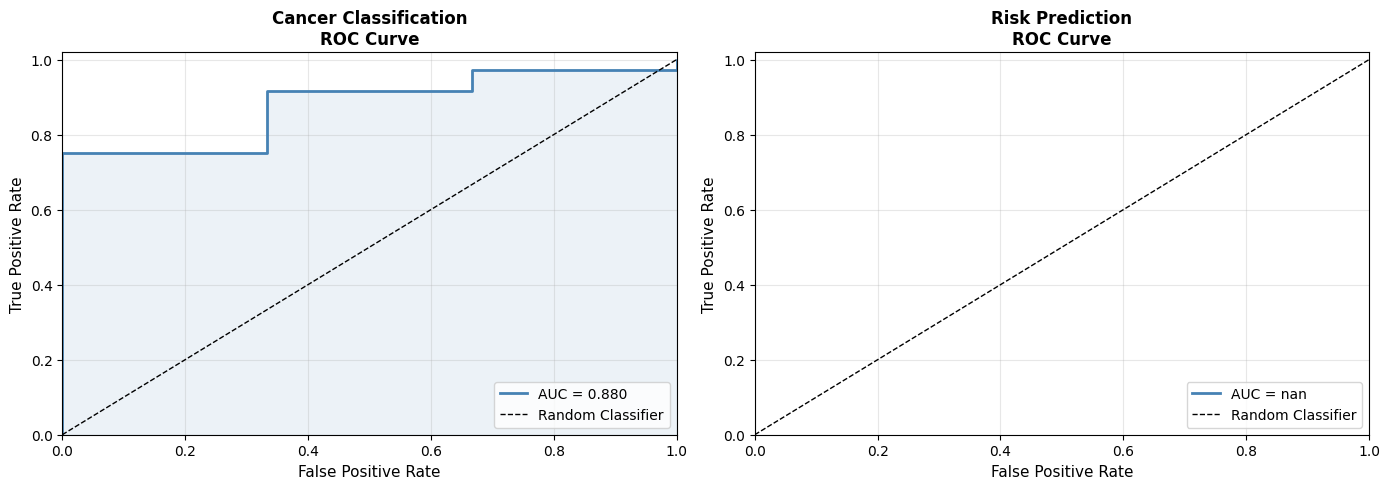

Saved roc_curves.png


In [25]:
#  ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_true, y_prob, auc_val, title in [
    (axes[0], all_cancer_true, all_cancer_prob, c_auc, 'Cancer Classification'),
    (axes[1], all_risk_true,   all_risk_prob,   r_auc, 'Risk Prediction'),
]:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    ax.plot(fpr, tpr, color='steelblue', lw=2,
            label=f'AUC = {auc_val:.3f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
    ax.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate',  fontsize=11)
    ax.set_title(f'{title}\nROC Curve', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right'); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved roc_curves.png')

In [26]:
#  Summary Table
print('\n' + '='*55)
print('         FINAL RESULTS SUMMARY')
print('='*55)
print(f'{'Task':<30} {'Accuracy':<12} {'AUC-ROC'}')
print('-'*55)

cancer_acc = accuracy_score(all_cancer_true, all_cancer_pred)
risk_acc   = accuracy_score(all_risk_true,   all_risk_pred)

print(f'{'Cancer Classification':<30} {cancer_acc:.4f}       {c_auc:.4f}')
print(f'{'Risk Prediction':<30} {risk_acc:.4f}       {r_auc:.4f}')
print('='*55)


         FINAL RESULTS SUMMARY
Task                           Accuracy     AUC-ROC
-------------------------------------------------------
Cancer Classification          0.9844       0.8801
Risk Prediction                1.0000       nan
